# First directive plot `Chromosome-to-chromosome vs Pole-to-chromosome`

In [1]:
import pandas as pd
import numpy as np
import os
import scipy.stats as stats 
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# input folder 
file_path = "D:/data/Analysis Data/python_analysis/input"

# output folder
folder_save = "D:/data/Analysis Data/python_analysis/output"

-2.69379027458904


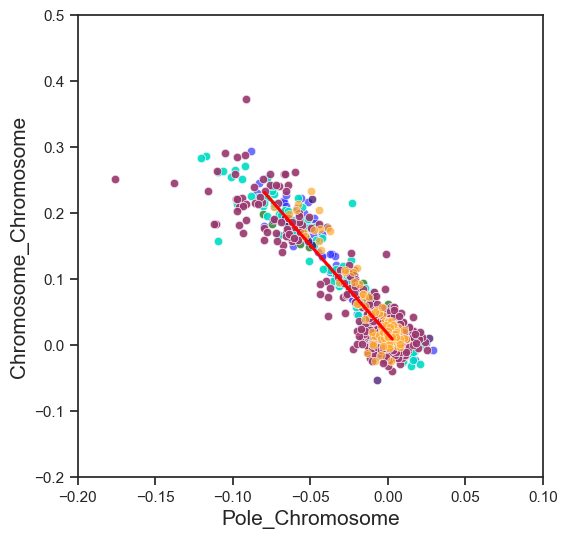

In [3]:
# read into the path directory of the files
df1=None
df2=None

with os.scandir(file_path) as data_files:
    for i in data_files:
        
        # for Chromosome-to-chromosome first derivative file
        if i.name.startswith('C_C'):
            df1 = pd.read_csv(i, index_col=None)
            new_df1 = df1.loc[:, df1.columns.str.contains('-cell')]
            time_column = df1.loc[:, df1.columns.str.contains('Time')]
            
            x_start = np.where(time_column >= 0)[0][0]
            x_end = np.where((time_column <= 154.5) & (time_column == 154.5))[0][0] + 1
            
            new_time_column = time_column[x_start:x_end]
            new_data_df1 = new_df1[x_start:x_end]
            df1_table = pd.concat([new_time_column, new_data_df1], axis=1)
          
        # for pole-to-chromosome first derivative file  
        if i.name.startswith('P_C'):
            df2 = pd.read_csv(i, index_col=None)
            new_df2 = df2.loc[:, df2.columns.str.contains('-cell')]
            time_column_df2 = df2.loc[:, df2.columns.str.contains('Time')]
            
            x_start = np.where(time_column >= 0)[0][0]
            x_end = np.where((time_column <= 154.5) & (time_column == 154.5))[0][0] + 1
            
            new_time_column_df2 = time_column_df2[x_start:x_end]
            new_data_df2 = new_df2[x_start:x_end]
            df2_table = pd.concat([new_time_column_df2, new_data_df2], axis=1)
            
# create a new dataframe            
df = pd.concat([df1_table, df2_table])

mean_df1_table = np.mean(df1_table.iloc[:, 1:], axis=1)
mean_df2_table = np.mean(df2_table.iloc[:, 1:], axis=1) 
df1_table['mean_C_C'] = mean_df1_table
df2_table['mean_P_C'] = mean_df2_table      

'''Activate the first block of code if the input files contains data for 1-cell, if not, comment out'''
# colors = {'1-cell': '#CC2EA5', 
#           '2-cell': '#006600', 
#          '4-cell': '#330066',
#          '8-cell': '#FFAA33',
#          '16-cell': '#3333FF',
#          '32-cell': '#00FFFF',
#          '64-cell': '#b84873'}

colors = {'2-cell': '#006600', 
         '4-cell': '#330066',
         '8-cell': '#FFAA33',
         '16-cell': '#3333FF',
         '32-cell': '#00FFFF',
         '64-cell': '#b84873'}

# dataframe
Slope_table = pd.DataFrame()

# define the shape and size of the plot
plt.figure(figsize=(6,6))

# Create the scatter plot using zip
sns.set(style="ticks")

for col1, col2 in zip(df1_table.columns, df2_table.columns):
    
    for cellStage in colors.keys():
        if cellStage in col1 and cellStage in col2:
            ax = sns.scatterplot(data=df, x=df2_table[col2], y=df1_table[col1], 
                                 color=colors[cellStage], 
                                 alpha=0.7)
            
            # Perform linear regression and get the slope
            slope, _, _, _, _ = stats.linregress(df2_table[col2], df1_table[col1])
            
            # create a new dictionary for the slope values
            parameter = {f"{col1} vs {col2}": slope}
            
            # create a dataframe from the dictionary above 
            parameters_df = pd.DataFrame.from_dict(parameter, orient='index', columns=['Slope'])
            
            # merge the dataframe to the empty dataframe
            Slope_table = pd.concat([Slope_table, parameters_df], axis=0)

# index header
Slope_table.index.names = ['Cells']

# Fit a linear regression line
ax1 = sns.regplot(data=df, x=df2_table['mean_P_C'], y=df1_table['mean_C_C'], 
                  color='red', 
                  scatter=False, 
                  fit_reg=True, 
                  ci=False, 
                  # label='Regression line', 
                  ax=ax)

# Get the regression line data
line_data = ax1.get_lines()[0].get_data()

# Calculate the slope and intercept
reg_slope = (line_data[1][1] - line_data[1][0]) / (line_data[0][1] - line_data[0][0])
print(reg_slope)
        
# set labels and title
ax.set_xlabel('Pole_Chromosome', fontsize=15)
ax.set_ylabel('Chromosome_Chromosome', fontsize=15)
# ax.set_title('First derivative (ani2-RNAi) \nChromosome-to-chromosome vs Pole-to-chromosome', fontsize=15)
# ax.set_title('First derivative (Wild-type) \nChromosome-to-chromosome vs Pole-to-chromosome', fontsize=15)
ax.set(xlim=(-0.2, 0.1),
        ylim=(-0.2, 0.5))

# save the plots in different formats
ax.figure.savefig(os.path.join(folder_save, 'First Derivative_C-C_vs_P-C.png'), dpi=600)
ax.figure.savefig(os.path.join(folder_save, 'First Derivative_C-C_vs_P-C.svg'), dpi=600)

# save the slope values to csv file
Slope_table.to_csv(os.path.join(folder_save, 'Slope_values_C-C_vs_P-C.csv'))